# e-commerce sales analysis

## project overview

this project analyzes e-commerce sales data to identify sales trends, customer behavior, product performance, regional performance, and key business metrics.

## objectives

- analyze overall sales performance
- identify top-performing products and categories
- analyze regional sales
- understand customer behavior
- analyze monthly sales trends
- calculate important business kpis
- create visualizations for better decision-making


import libraries
↓
load dataset
↓
data inspection
↓
data cleaning
↓
analysis
↓
visualizations
↓
insights

In [183]:
import pandas as pd

sales_df =pd.read_csv("/kaggle/input/datasets/abedmiah/sales-34500/ecommerce_sales_34500.csv")
sales_df.head(5)

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [184]:
print(sales_df.shape)
print(sales_df.columns)

(34500, 17)
Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='object')


In [185]:
print(sales_df.info())
print(sales_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [186]:
sales_df["order_date"] = pd.to_datetime(sales_df["order_date"])
print(sales_df["order_date"].dtype)

datetime64[ns]


In [187]:
category_sales= sales_df.groupby("category")["total_amount"].sum()

print(category_sales)

category
Beauty          153019.38
Electronics    3319206.50
Fashion         471545.80
Grocery          82000.51
Home           1077681.52
Sports          629825.54
Toys            132013.80
Name: total_amount, dtype: float64


In [188]:
print(category_sales.idxmax())

Electronics


In [189]:
regionwise_sales= sales_df.groupby("region")["total_amount"].sum()

print(regionwise_sales)

print(regionwise_sales.idxmax())

region
Central     940503.38
East       1176334.75
North      1264008.35
South      1298096.07
West       1186350.50
Name: total_amount, dtype: float64
South


In [190]:
payment_count=sales_df["payment_method"].value_counts()

print(payment_count)

print(payment_count.idxmax())

payment_method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
PayPal          3444
Wallet          2065
Name: count, dtype: int64
Credit Card


In [191]:
age_group= pd.cut(
    sales_df["customer_age"],
    bins=[17,25,35,45,55,70],
    labels=["18-25", "26-35","36-45","46-55","56+"]
    

    
)

print(age_group.value_counts())

customer_age
56+      9237
36-45    6678
26-35    6678
46-55    6609
18-25    5298
Name: count, dtype: int64


In [192]:
print(age_group.value_counts(). idxmax())

56+


In [193]:
return_count=sales_df["returned"].value_counts()

print(return_count)

returned
No     32597
Yes     1903
Name: count, dtype: int64


In [194]:
return_rate=(sales_df["returned"] =="Yes").mean() *100

print(return_rate)

5.515942028985507


In [195]:
category_profit=sales_df.groupby("category")["profit_margin"].sum()

print(category_profit)

print(category_profit. idxmax())

category
Beauty          49196.59
Electronics    344371.77
Fashion        128814.65
Grocery         -9187.96
Home           262633.70
Sports         160521.41
Toys            33669.25
Name: profit_margin, dtype: float64
Electronics


In [196]:
average_order=sales_df["total_amount"].mean()
print(average_order)

170.00849420289856


In [197]:
sales_df["month"]=sales_df["order_date"].dt.strftime("%B")

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales= sales_df.groupby("month")["total_amount"].sum().reindex(month_order)

print(monthly_sales)

month
January      442156.30
February     443352.17
March        487523.09
April        528620.69
May          513402.69
June         482931.66
July         502962.90
August       456421.70
September    461857.67
October      521434.01
November     490858.95
December     533771.22
Name: total_amount, dtype: float64


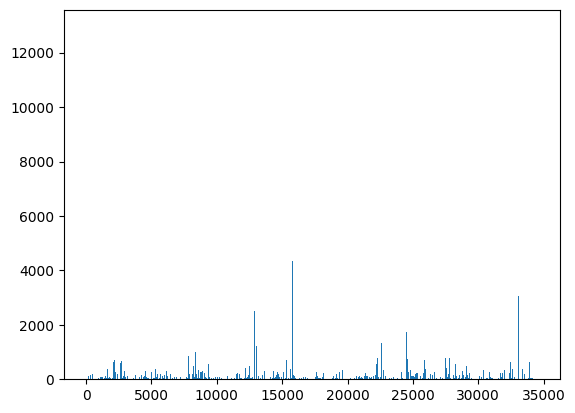

In [198]:
import matplotlib.pyplot as plt

plt.bar(sales_df.index, sales_df.total_amount)

plt.show()

In [199]:
abeddifa=sales_df.copy()
abeddifa

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,month
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female,December
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male,April
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male,October
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female,September
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male,December
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,O134495,C13553,P231412,Fashion,10.44,0.20,1,Debit Card,2025-08-13,3,North,No,8.35,3.04,-0.12,23,Female,August
34496,O134496,C11349,P218266,Beauty,4.79,0.10,5,Debit Card,2023-12-04,6,South,Yes,21.56,3.37,6.33,61,Female,December
34497,O134497,C12986,P204345,Electronics,323.64,0.00,5,Credit Card,2025-02-01,6,East,No,1618.20,12.18,182.00,41,Female,February
34498,O134498,C17196,P217644,Home,23.09,0.05,1,Credit Card,2024-03-27,6,East,No,21.94,5.61,0.53,27,Female,March


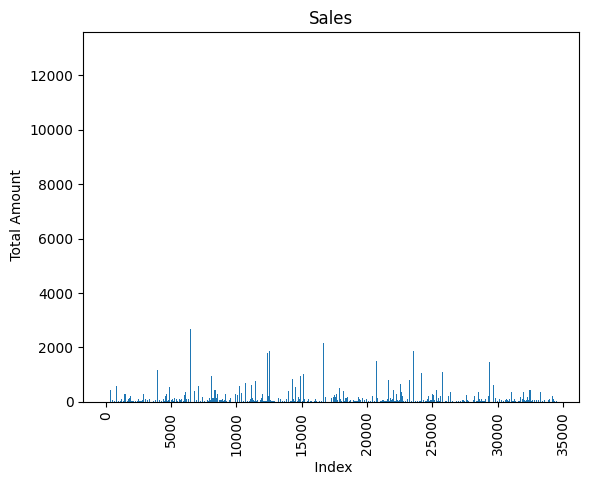

In [200]:
plt.bar(abeddifa.index , abeddifa.total_amount)

plt.xlabel(" Index")
plt.ylabel(" Total Amount")
plt.title("Sales")
plt.xticks(rotation=90)
plt.show()

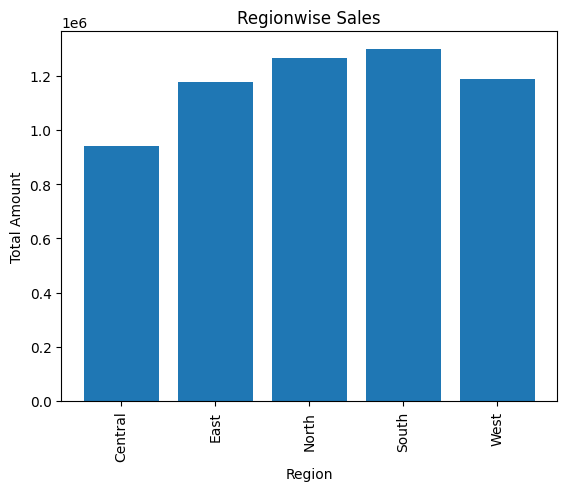

In [201]:
region_sales=abeddifa.groupby("region")["total_amount"].sum()

plt.bar(region_sales.index, region_sales.values)

plt.xlabel("Region")
plt.ylabel("Total Amount")
plt.title("Regionwise Sales")

plt.xticks(rotation=90)
plt.show()

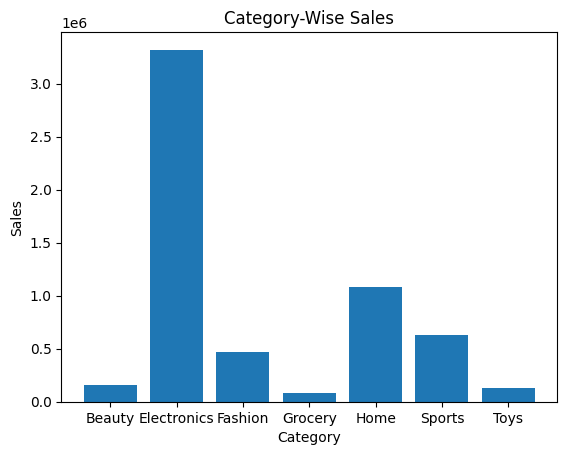

In [202]:
category_sales= abeddifa.groupby("category")["total_amount"].sum()

plt.bar(category_sales.index, category_sales.values)

plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Category-Wise Sales")

plt.show()

In [203]:
payment_count=abeddifa["payment_method"].value_counts()

payment_count

payment_method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
PayPal          3444
Wallet          2065
Name: count, dtype: int64

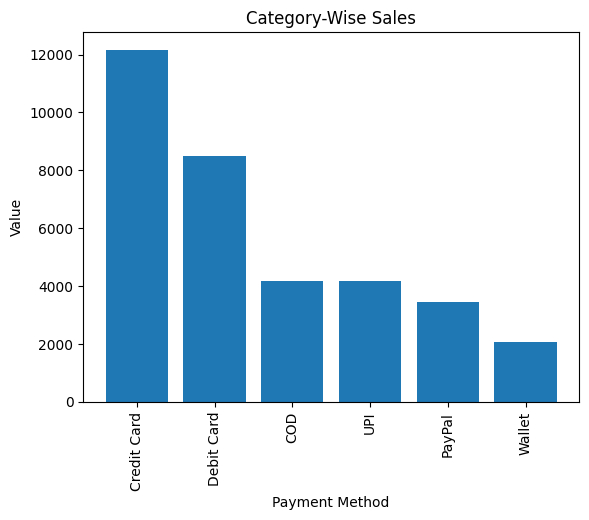

In [204]:
payment_count=abeddifa["payment_method"].value_counts()

plt.bar(payment_count.index , payment_count.values)

plt.xlabel("Payment Method")
plt.ylabel("Value")
plt.title("Category-Wise Sales")

plt.xticks(rotation=90)

plt.show()

In [205]:

print("average delivery:", abeddifa["delivery_time_days"].mean())


print("return count:")
print(abeddifa["returned"].value_counts())


print("gender:")
print(abeddifa["customer_gender"].value_counts())

print("average age:", abeddifa["customer_age"].mean())

average delivery: 4.814202898550724
return count:
returned
No     32597
Yes     1903
Name: count, dtype: int64
gender:
customer_gender
Female    16818
Male      16310
Other      1372
Name: count, dtype: int64
average age: 43.474376811594205


In [206]:
print("total sales:", abeddifa["total_amount"].sum())
print("total orders:", len(abeddifa))
print("average order:", abeddifa["total_amount"].mean())
print("total quantity:", abeddifa["quantity"].sum())
print("average delivery:", abeddifa["delivery_time_days"].mean())
print("average discount:", abeddifa["discount"].mean())
print("average profit:", abeddifa["profit_margin"].mean())

total sales: 5865293.050000001
total orders: 34500
average order: 170.00849420289856
total quantity: 51430
average delivery: 4.814202898550724
average discount: 0.049291304347826095
average profit: 28.116504637681157


In [207]:
top_products=abeddifa.groupby("product_id")["total_amount"].sum()

top_5=top_products.sort_values(ascending=False).head(5)

print(top_5)


product_id
P217031    13035.01
P242326    11747.30
P224743    11298.30
P216077     8035.78
P225406     6786.53
Name: total_amount, dtype: float64


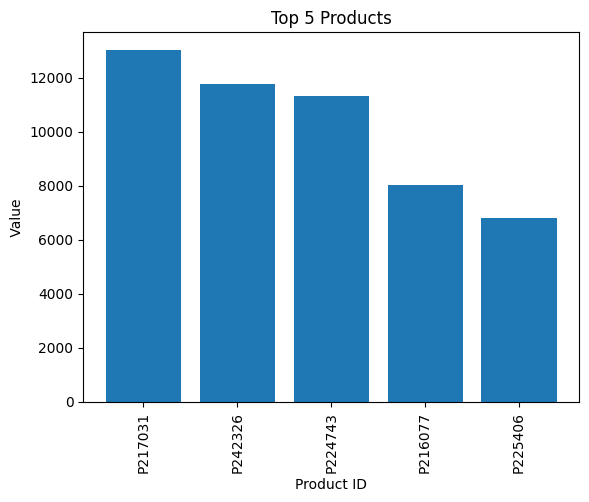

In [208]:
plt.bar(top_5.index, top_5.values)

plt.xlabel("Product ID")
plt.ylabel(" Value ")
plt.title("Top 5 Products")

plt.xticks(rotation=90)

plt.show()

In [209]:
print("Best Region is : " , abeddifa.groupby("region")["total_amount"].sum(). idxmax())
print("Best Category is : " , abeddifa.groupby("category")["total_amount"].sum(). idxmax())


Best Region is :  South
Best Category is :  Electronics


In [210]:
print("total sales:", abeddifa["total_amount"].sum())
print("total orders:", len(abeddifa))
print("total quantity:", abeddifa["quantity"].sum())
print("average order:", abeddifa["total_amount"].mean())
print("best region:", abeddifa.groupby("region")["total_amount"].sum().idxmax())
print("best category:", abeddifa.groupby("category")["total_amount"].sum().idxmax())

total sales: 5865293.050000001
total orders: 34500
total quantity: 51430
average order: 170.00849420289856
best region: South
best category: Electronics


In [211]:
print("total sales:", abeddifa["total_amount"].sum())
print("total orders:", len(abeddifa))
print("total quantity:", abeddifa["quantity"].sum())
print("avg order:", abeddifa["total_amount"].mean())
print("avg delivery:", abeddifa["delivery_time_days"].mean())
print("return rate:", (abeddifa["returned"] == "Yes").mean() * 100)

total sales: 5865293.050000001
total orders: 34500
total quantity: 51430
avg order: 170.00849420289856
avg delivery: 4.814202898550724
return rate: 5.515942028985507


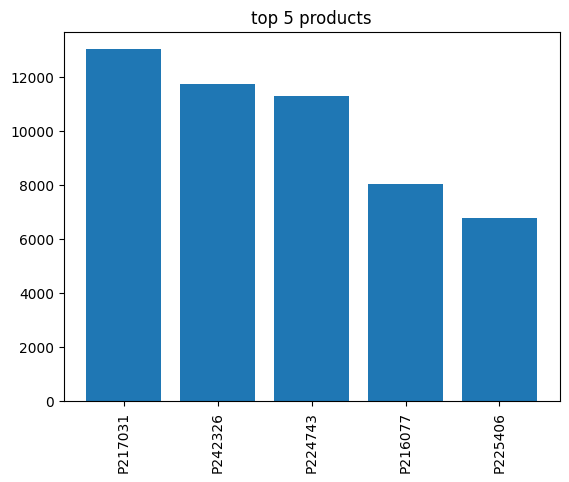

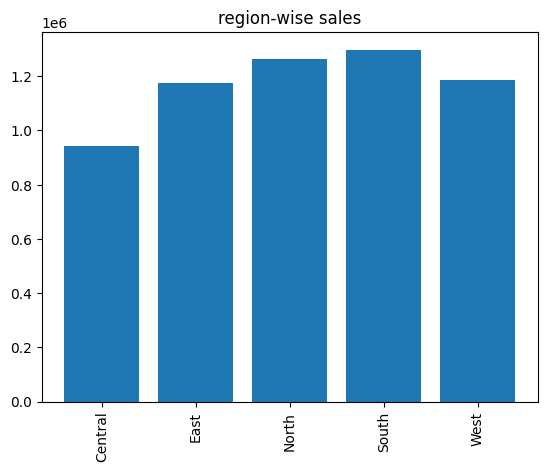

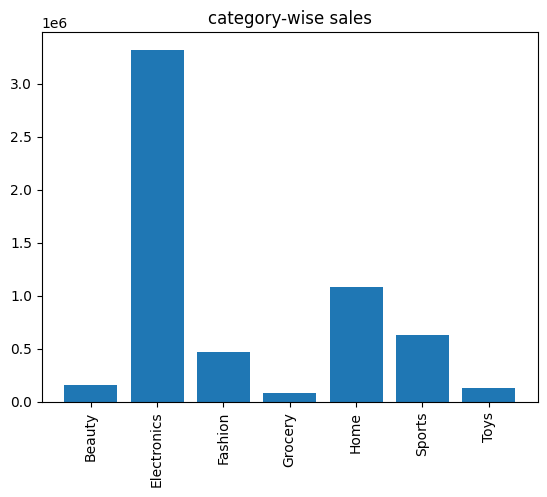

In [212]:
# product
product_sales = abeddifa.groupby("product_id")["total_amount"].sum().nlargest(5)
plt.bar(product_sales.index, product_sales.values)
plt.title("top 5 products")
plt.xticks(rotation=90)
plt.show()

# region
region_sales = abeddifa.groupby("region")["total_amount"].sum()
plt.bar(region_sales.index, region_sales.values)
plt.title("region-wise sales")
plt.xticks(rotation=90)
plt.show()

# category
category_sales = abeddifa.groupby("category")["total_amount"].sum()
plt.bar(category_sales.index, category_sales.values)
plt.title("category-wise sales")
plt.xticks(rotation=90)
plt.show()

In [213]:
print("total sales:", abeddifa["total_amount"].sum())
print("total orders:", len(abeddifa))
print("total quantity:", abeddifa["quantity"].sum())
print("average order:", abeddifa["total_amount"].mean())
print("average delivery:", abeddifa["delivery_time_days"].mean())
print("return rate:", (abeddifa["returned"] == "Yes").mean() * 100)

print("best category:",
      abeddifa.groupby("category")["total_amount"].sum().idxmax())

print("best region:",
      abeddifa.groupby("region")["total_amount"].sum().idxmax())

print("best payment method:",
      abeddifa["payment_method"].value_counts().idxmax())

total sales: 5865293.050000001
total orders: 34500
total quantity: 51430
average order: 170.00849420289856
average delivery: 4.814202898550724
return rate: 5.515942028985507
best category: Electronics
best region: South
best payment method: Credit Card


## data inspection

before performing the analysis, we inspect the dataset structure, data types, missing values, and basic statistics.

In [214]:
print(abeddifa.shape)
abeddifa.info()
abeddifa.describe()

(34500, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  object        
 1   customer_id         34500 non-null  object        
 2   product_id          34500 non-null  object        
 3   category            34500 non-null  object        
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  object        
 8   order_date          34500 non-null  datetime64[ns]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  object        
 11  returned            34500 non-null  object        
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null

,price,discount,quantity,order_date,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,2024-09-13 13:39:17.843478272,4.814203,170.008494,6.152120,28.116505,43.474377
min,1.010000,0.000000,1.000000,2023-09-12 00:00:00,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,2024-03-14 00:00:00,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,2024-09-16 00:00:00,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,2025-03-17 00:00:00,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,2025-09-11 00:00:00,13.000000,12931.800000,15.650000,1536.170000,69.000000
std,195.620477,0.069894,0.932270,NaN,1.242141,357.503014,2.389539,53.352947,14.980682


## data cleaning

the dataset was checked for missing values and duplicate records before analysis.

In [215]:
print("missing values:")
print(abeddifa.isnull().sum())

print("duplicate rows:", abeddifa.duplicated().sum())

missing values:
order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
month                 0
dtype: int64
duplicate rows: 0


## data preparation

the order date was converted into datetime format to enable time-based analysis.


In [216]:
abeddifa["order_date"] = pd.to_datetime(abeddifa["order_date"])

print(abeddifa["order_date"].dtype)

datetime64[ns]


## business analysis

key sales, product, category, regional, customer, and payment metrics are analyzed below.

# final sales dashboard

this dashboard presents the key business performance metrics and major sales insights from the e-commerce dataset.

In [217]:
import pandas as pd
import matplotlib.pyplot as plt

# prepare month data
abeddifa["month"] = abeddifa["order_date"].dt.strftime("%B").str.lower()

month_order = [
    "january", "february", "march", "april",
    "may", "june", "july", "august",
    "september", "october", "november", "december"
]

monthly_sales = (
    abeddifa.groupby("month")["total_amount"]
    .sum()
    .reindex(month_order)
    .dropna()
)

# kpis
total_sales = abeddifa["total_amount"].sum()
total_orders = len(abeddifa)
total_quantity = abeddifa["quantity"].sum()
average_order = abeddifa["total_amount"].mean()
average_delivery = abeddifa["delivery_time_days"].mean()

return_rate = (
    abeddifa["returned"]
    .astype(str)
    .str.lower()
    .eq("yes")
    .mean() * 100
)

# top product
top_product = (
    abeddifa.groupby("product_id")["total_amount"]
    .sum()
    .idxmax()
)

# best category
best_category = (
    abeddifa.groupby("category")["total_amount"]
    .sum()
    .idxmax()
)

# best region
best_region = (
    abeddifa.groupby("region")["total_amount"]
    .sum()
    .idxmax()
)

# best payment method
best_payment = (
    abeddifa["payment_method"]
    .value_counts()
    .idxmax()
)

print("total sales:", round(total_sales, 2))
print("total orders:", total_orders)
print("total quantity:", total_quantity)
print("average order:", round(average_order, 2))
print("average delivery:", round(average_delivery, 2), "days")
print("return rate:", round(return_rate, 2), "%")
print("top product:", top_product)
print("best category:", best_category)
print("best region:", best_region)
print("best payment method:", best_payment)

total sales: 5865293.05
total orders: 34500
total quantity: 51430
average order: 170.01
average delivery: 4.81 days
return rate: 5.52 %
top product: P217031
best category: Electronics
best region: South
best payment method: Credit Card


## sales visualizations

the following charts highlight product performance, regional sales, category performance, payment preferences, and monthly sales trends.

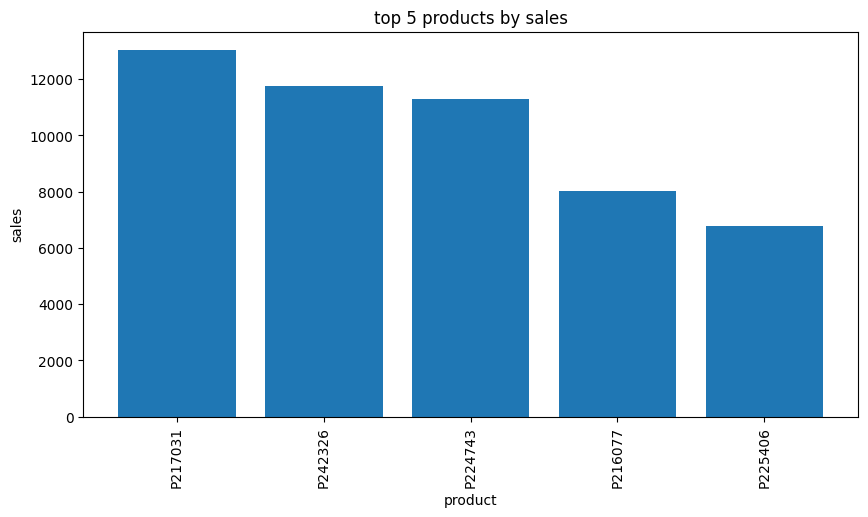

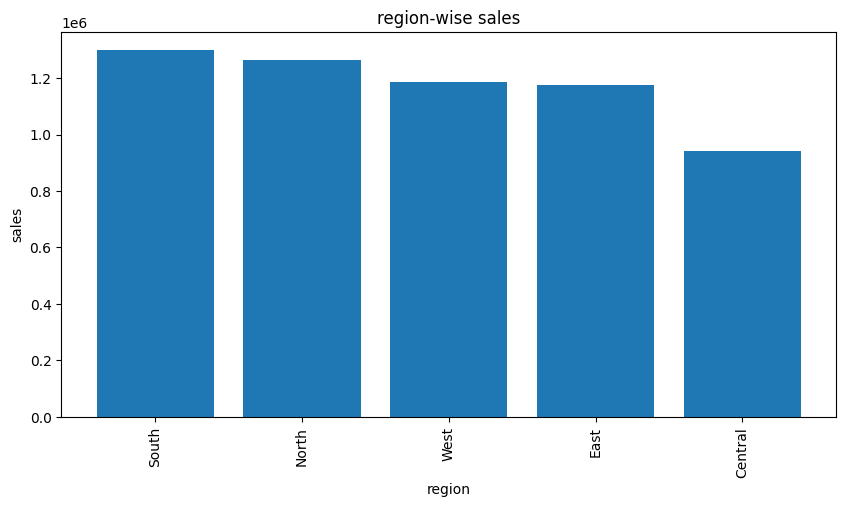

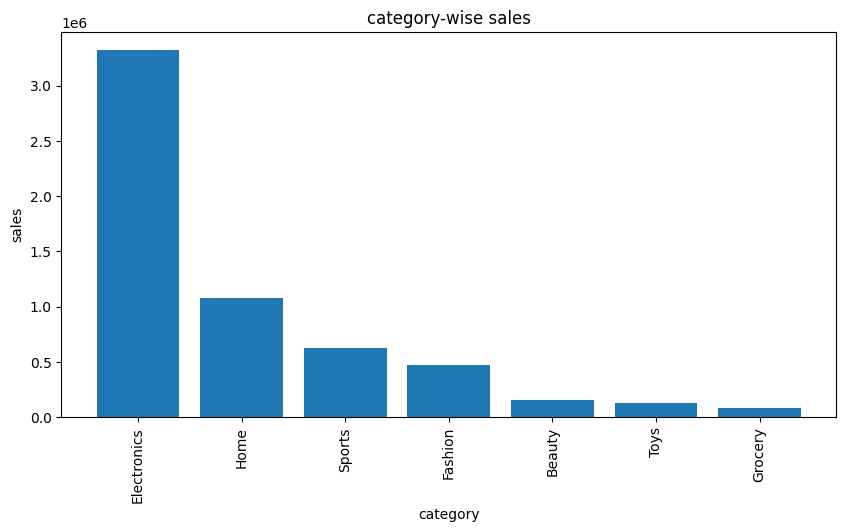

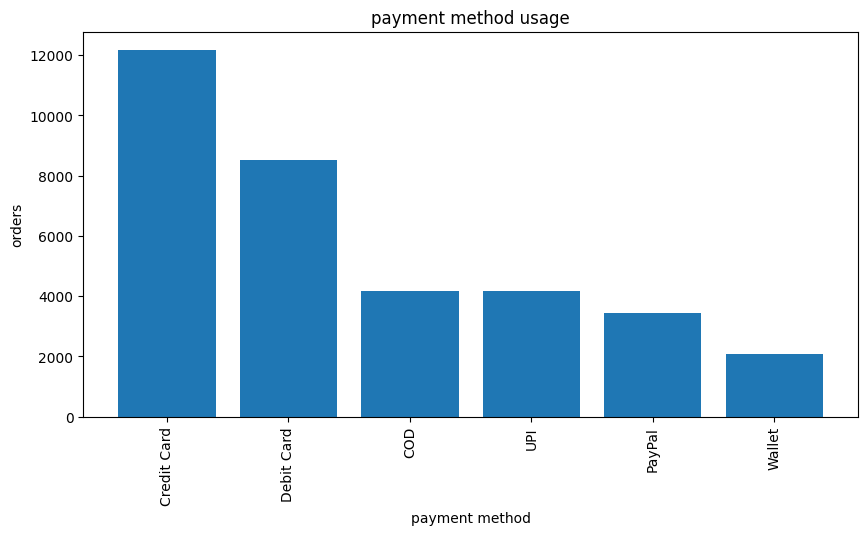

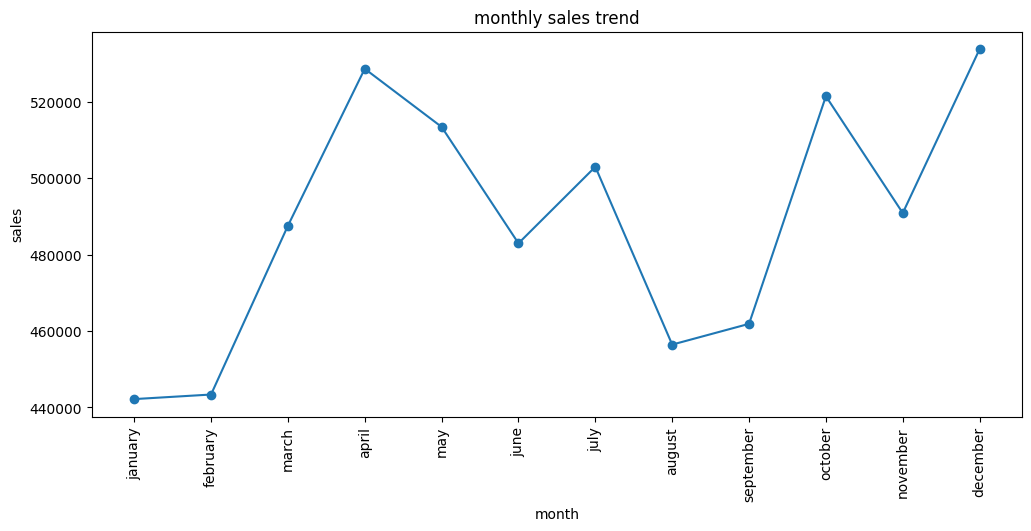

In [218]:
# top 5 products
product_sales = (
    abeddifa.groupby("product_id")["total_amount"]
    .sum()
    .nlargest(5)
)

plt.figure(figsize=(10, 5))
plt.bar(product_sales.index.astype(str), product_sales.values)
plt.title("top 5 products by sales")
plt.xlabel("product")
plt.ylabel("sales")
plt.xticks(rotation=90)
plt.show()


# region-wise sales
region_sales = (
    abeddifa.groupby("region")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(region_sales.index, region_sales.values)
plt.title("region-wise sales")
plt.xlabel("region")
plt.ylabel("sales")
plt.xticks(rotation=90)
plt.show()


# category-wise sales
category_sales = (
    abeddifa.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(category_sales.index, category_sales.values)
plt.title("category-wise sales")
plt.xlabel("category")
plt.ylabel("sales")
plt.xticks(rotation=90)
plt.show()


# payment method usage
payment_count = abeddifa["payment_method"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(payment_count.index, payment_count.values)
plt.title("payment method usage")
plt.xlabel("payment method")
plt.ylabel("orders")
plt.xticks(rotation=90)
plt.show()


# monthly sales
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("monthly sales trend")
plt.xlabel("month")
plt.ylabel("sales")
plt.xticks(rotation=90)
plt.show()

## key business insights

### sales performance

the dataset contains a large number of e-commerce transactions with measurable sales, order volume, and product demand.

### product performance

the top-performing products contribute significantly to overall sales and can be prioritized for inventory and marketing activities.

### category performance

the best-performing category indicates where customer demand is strongest.

### regional performance

the highest-performing region can be targeted with stronger marketing and promotional campaigns.

### customer behavior

customer age and gender distributions provide useful information for customer segmentation and targeted marketing.

### payment behavior

the most frequently used payment method indicates the preferred payment option among customers.

### delivery performance

average delivery time provides a useful operational benchmark for evaluating the customer experience.

### return behavior

the return rate can help identify potential issues with product quality, customer expectations, or order fulfillment.

## conclusion

this analysis provides an overview of e-commerce sales performance across products, categories, regions, customers, payment methods, and time periods.

the analysis can help businesses identify high-performing products, understand customer demand, improve regional marketing strategies, and monitor important operational kpis.

the project demonstrates practical skills in python, pandas, data analysis, and data visualization.